<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/Day6/%20Day6Supervised_Learning_Foundations_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_maintenance(csv_path="machine_maintenance.csv", seed=14, verbose=False):
    """Predictive maintenance: predict whether a machine will FAIL from its
    operating conditions. A realistic, imbalanced binary-classification problem —
    perfect for the full supervised workflow and comparing model families.

    Features:
      machine_type        product quality variant (L / M / H)
      air_temperature_k    ambient temperature (K)
      process_temperature_k process temperature (K)
      rotational_speed_rpm spindle speed (rpm)
      torque_nm            torque (Nm)
      tool_wear_min        cumulative tool wear (minutes)
    Target:
      machine_failure      1 = failed, 0 = healthy
    """
    rng = np.random.default_rng(seed)
    N = 3000
    mtype = rng.choice(["L", "M", "H"], N, p=[0.50, 0.30, 0.20])
    air = rng.normal(300, 2.0, N)
    process = air + 10 + rng.normal(0, 1.0, N)
    speed = np.clip(rng.normal(1540, 170, N), 1168, 2886).round().astype(int)
    torque = np.clip(rng.normal(40, 10, N), 3, 77).round(1)
    wear = rng.uniform(0, 253, N).round().astype(int)
    type_eff = np.select([mtype == "L", mtype == "M", mtype == "H"], [0.6, 0.0, -0.5])

    # failure risk: worn tools, high torque, an overstrain interaction, and poor heat dissipation
    heat_bad = ((process - air) < 8.6).astype(float)
    z = (-5.2
         + 0.012 * wear
         + 0.06 * (torque - 40)
         + 4.0e-4 * wear * (torque - 40)
         + 0.7 * heat_bad
         + type_eff)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "machine_type": mtype,
        "air_temperature_k": air.round(1),
        "process_temperature_k": process.round(1),
        "rotational_speed_rpm": speed,
        "torque_nm": torque,
        "tool_wear_min": wear,
        "machine_failure": failure,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("maintenance:", df.shape)
        print("failure rate:", round(df.machine_failure.mean(), 3))
        print("failures by type:\n",
              df.groupby("machine_type")["machine_failure"].mean().round(3).to_string())
    return df

if not os.path.exists('machine_maintenance.csv'):
    build_maintenance(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_maintenance.csv')
print('shape:', df.shape)
print('failure rate:', round(df['machine_failure'].mean(), 3))
df.head(3)

shape: (3000, 7)
failure rate: 0.074


,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,H,298.8,309.2,1704,29.4,224,0
1,L,299.2,312.4,1611,36.9,178,0
2,M,301.8,310.4,1243,23.6,27,0


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_maintenance.csv')
print('shape:', df.shape)
print('failure rate:', round(df['machine_failure'].mean(), 3))
df.head(3)

shape: (3000, 7)
failure rate: 0.074


,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,H,298.8,309.2,1704,29.4,224,0
1,L,299.2,312.4,1611,36.9,178,0
2,M,301.8,310.4,1243,23.6,27,0


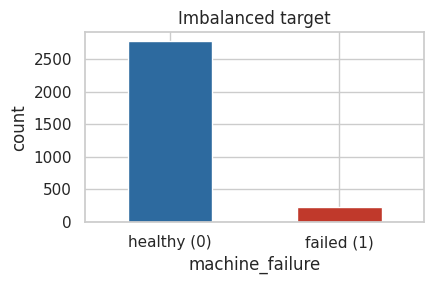

X: (3000, 6) | classification, 2 classes
Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.


In [4]:
# -----------------------------------------------------------
# 🔹 1A. TARGET BALANCE + FEATURES / TARGET
# -----------------------------------------------------------
ax = df['machine_failure'].value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], figsize=(4.5, 3))
ax.set_xticklabels(['healthy (0)', 'failed (1)'], rotation=0); ax.set_ylabel('count')
ax.set_title('Imbalanced target'); plt.tight_layout(); plt.show()

y = df['machine_failure']
X = df.drop(columns='machine_failure')
print('X:', X.shape, '| classification, 2 classes')
print('Because failures are rare, ACCURACY will be misleading — watch recall/F1/AUC.')

In [5]:
# -----------------------------------------------------------
# 🔹 2A. PREPROCESS (encode + scale) + A FIRST MODEL
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num = X.select_dtypes('number').columns.tolist()
cat = ['machine_type']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), cat)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

clf = Pipeline([('prep', pre), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)                 # FIT — learn from training data
preds = clf.predict(X_test)               # PREDICT — apply to unseen data
print('score (accuracy):', round(clf.score(X_test, y_test), 3))

score (accuracy): 0.736


In [6]:
# 1. always-healthy accuracy
dummy_acc = 1 - y_test.mean()
print("Always healthy accuracy:", round(dummy_acc, 3))

# 2-3. compare & explain:
# The dummy classifier can achieve high accuracy because failures are rare.
# However, it never identifies any failures, making it useless for predictive maintenance.
# Therefore, accuracy alone is misleading on imbalanced datasets.

Always healthy accuracy: 0.925


In [7]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN FOUR FAMILIES, COMPARE ON TEST
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'kNN': KNeighborsClassifier(n_neighbors=15),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
}
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name,
                 'F1': f1_score(y_test, pipe.predict(X_test)),
                 'ROC_AUC': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                 F1  ROC_AUC
model                       
LogReg        0.322    0.870
DecisionTree  0.252    0.736
kNN           0.159    0.810
RandomForest  0.094    0.838


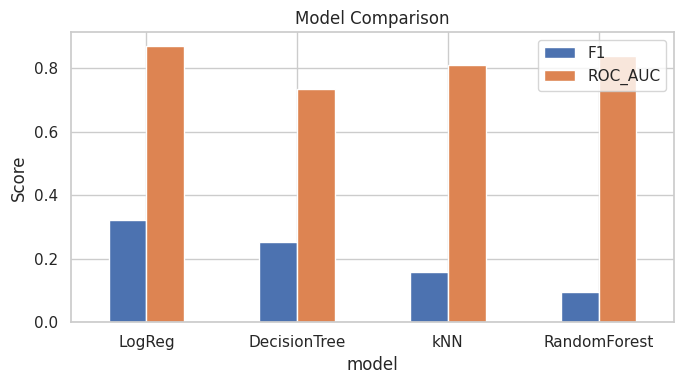

Best model: LogReg
Margin over Logistic Regression: 0.0


In [8]:
# 1. bar chart of the comparison

results.plot(kind='bar', figsize=(7,4))
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. best model & margin:
best_model = results['ROC_AUC'].idxmax()
margin = results.loc[best_model, 'ROC_AUC'] - results.loc['LogReg', 'ROC_AUC']

print("Best model:", best_model)
print("Margin over Logistic Regression:", round(margin, 3))

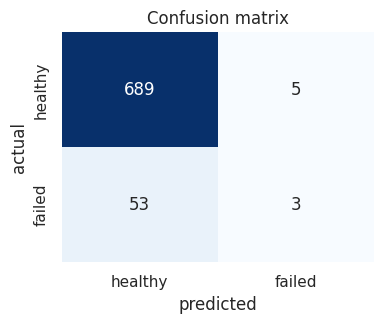

              precision    recall  f1-score   support

           0      0.929     0.993     0.960       694
           1      0.375     0.054     0.094        56

    accuracy                          0.923       750
   macro avg      0.652     0.523     0.527       750
weighted avg      0.887     0.923     0.895       750



In [9]:
# -----------------------------------------------------------
# 🔹 4A. CONFUSION MATRIX + FULL REPORT (random forest)
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
rf = Pipeline([('prep', pre), ('model', RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
cm = confusion_matrix(y_test, rf.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failed'], yticklabels=['healthy', 'failed'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()
print(classification_report(y_test, rf.predict(X_test), digits=3))


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf = Pipeline([
    ('prep', pre),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=0))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['air_temperature_k',
                                                   'process_temperature_k',
                                                   'rotational_speed_rpm',
                                                   'torque_nm',
                                                   'tool_wear_min']),
                                                 ('cat', OneHotEncoder(),
                                                  ['machine_type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=0))])

In [15]:
print('rf' in globals())
print('proba_rf' in globals())

True
False


In [16]:
from sklearn.metrics import recall_score

# create probability predictions
proba_rf = rf.predict_proba(X_test)[:, 1]

# lower threshold from 0.5 to 0.3
pred_03 = (proba_rf > 0.3).astype(int)

print("Recall at threshold 0.3:",
      recall_score(y_test, pred_03))

Recall at threshold 0.3: 0.25


In [17]:
# -----------------------------------------------------------
# 🔹 5A. 5-FOLD ROC-AUC (mean +/- std) PER MODEL
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('model', m)])
    s = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')
    print(f'{name:14s} ROC-AUC {s.mean():.3f} +/- {s.std():.3f}')

LogReg         ROC-AUC 0.857 +/- 0.016
DecisionTree   ROC-AUC 0.780 +/- 0.052
kNN            ROC-AUC 0.770 +/- 0.021
RandomForest   ROC-AUC 0.808 +/- 0.015


In [18]:
# 1. per-fold F1 for the random forest

from sklearn.model_selection import cross_val_score

rf_pipe = Pipeline([
    ('prep', pre),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=0))
])

f1_scores = cross_val_score(
    rf_pipe,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Per-fold F1 scores:")
print(f1_scores)

print("Mean F1:", round(f1_scores.mean(), 3))
print("Std F1:", round(f1_scores.std(), 3))

Per-fold F1 scores:
[0.28571429 0.         0.19230769 0.08510638 0.16      ]
Mean F1: 0.145
Std F1: 0.097


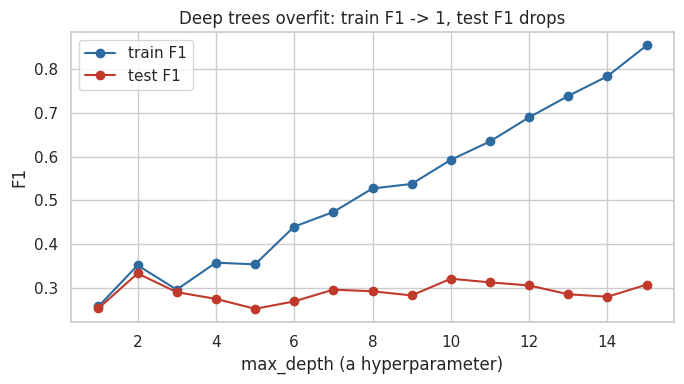

In [19]:
# -----------------------------------------------------------
# 🔹 6A. A HYPERPARAMETER (tree depth) DRIVES OVER/UNDERFIT
# -----------------------------------------------------------
depths = range(1, 16)
tr, te = [], []
for d in depths:
    p = Pipeline([('prep', pre), ('model', DecisionTreeClassifier(
        max_depth=d, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, p.predict(X_train)))
    te.append(f1_score(y_test, p.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train F1', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test F1', color='#C0392B')
ax.set_xlabel('max_depth (a hyperparameter)'); ax.set_ylabel('F1'); ax.legend()
ax.set_title('Deep trees overfit: train F1 -> 1, test F1 drops'); plt.tight_layout(); plt.show()

In [20]:
# 1. best max_depth by test F1

best_depth = depths[np.argmax(te)]
best_test_f1 = max(te)

print("Best max_depth:", best_depth)
print("Best test F1:", round(best_test_f1, 3))

Best max_depth: 2
Best test F1: 0.333
